1.向量点积
a⋅b=2×1+(−1)×4+3×(−2)=2−4−6=−8

2.矩阵乘法AB
AB=[1×2+0×0+2×3      ​1×1+0×(−1)+2×2
−1×2+3×0+1×3         −1×1+3×(−1)+1×2]=
[ 8 5
  ​1 −2]

3.向量a的 Frobenius 范数
||a||_F=√(2^2+(−1)^2+3^2)=√(4+1+9)=√14

In [ ]:
import numpy as np

# 1. 创建 3×4 的标准正态分布随机矩阵 X
X = np.random.randn(3, 4)
print("矩阵 X (3×4):")
print(X)
print("-" * 50)


# 2. 创建 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("矩阵 Y (4×2):")
print(Y)
print("-" * 50)


# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)  # 也可以用 @ 运算符：Z = X @ Y
print("矩阵 Z = X × Y (3×2):")
print(Z)
print("-" * 50)


# 4. 输出指定元素
# 注意：NumPy 索引从 0 开始，所以：
# 第一行第二列 → 索引 (0, 1)
# 第 2 行所有元素 → 索引 1
element = Z[0, 1]
second_row = Z[1, :]
print("Z 的第一行第二列交叉处的元素:", element)
print("Z 的第 2 行所有元素:", second_row)
print("-" * 50)


# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, ord='fro')
print("Z 的 Frobenius 范数:", frobenius_norm)

矩阵 X (3×4):
[[-0.1045538   0.8028195  -0.86786718  0.02894424]
 [ 1.6365186   1.11271296 -0.33190142 -0.24438281]
 [ 1.86854999  0.06179636 -0.76607738  0.58432536]]
--------------------------------------------------
矩阵 Y (4×2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
--------------------------------------------------
矩阵 Z = X × Y (3×2):
[[-0.14065724 -0.14065724]
 [ 2.17294733  2.17294733]
 [ 1.74859433  1.74859433]]
--------------------------------------------------
Z 的第一行第二列交叉处的元素: -0.1406572434649562
Z 的第 2 行所有元素: [2.17294733 2.17294733]
--------------------------------------------------
Z 的 Frobenius 范数: 3.949447225248227



设：A：事件 “患病”，则 A表示 “未患病”
B：事件 “检测结果为阳性”

患病率：P(A)=0.1%=0.001，则 P( A )=1−0.001=0.999
灵敏度（真阳性率）：P(B∣A)=99%=0.99
假阳性率：P(B∣ A )=2%=0.02
我们要求的是：检测为阳性时，真正患病的概率 P(A∣B)
P(A∣B)= P(B∣A)P(A)/P(B)
​
 
其中，全概率公式计算 
P(B)：P(B)=P(B∣A)P(A)+P(B∣A)P( A )

P(B)=0.99×0.001+0.02×0.999
=0.00099+0.01998
=0.02097
​
 
P(A∣B)= 0.99×0.001/0.02097
= 0.00099 / 0.02097
= 0.0472
​
 


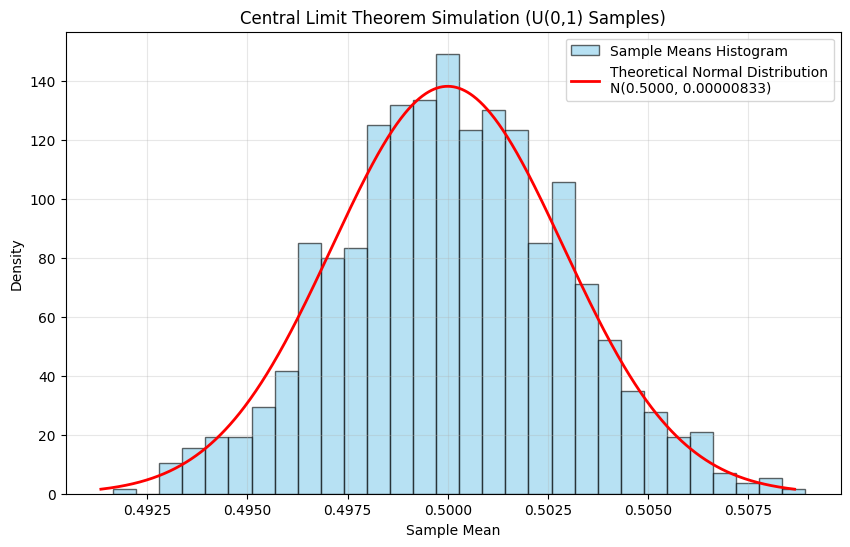

理论方差: 0.00000833
实际模拟的均值方差: 0.00000806


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# 1. 参数设置与模拟
# ----------------------
n = 10000  # 每次抽样的样本量
m = 1000   # 重复次数
means = []

# 重复m次，每次生成n个U(0,1)的样本并计算均值
for _ in range(m):
    samples = np.random.uniform(0, 1, size=n)
    means.append(np.mean(samples))

means = np.array(means)

# ----------------------
# 2. 理论正态分布参数
# ----------------------
# U(0,1)的均值 μ=0.5，方差 σ²=1/12
mu_theory = 0.5
var_theory = (1/12) / n  # 样本均值的方差
std_theory = np.sqrt(var_theory)

# ----------------------
# 3. 绘制直方图与理论曲线（不用scipy）
# ----------------------
plt.figure(figsize=(10, 6))
# 直方图（density=True 让直方图和概率密度函数对齐）
plt.hist(means, bins=30, density=True, alpha=0.6, 
         color='skyblue', edgecolor='black', label='Sample Means Histogram')

# 手动实现正态分布PDF，替代scipy.stats.norm.pdf
def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

x = np.linspace(mu_theory - 3*std_theory, mu_theory + 3*std_theory, 1000)
pdf = normal_pdf(x, mu_theory, std_theory)
plt.plot(x, pdf, 'r-', lw=2, 
         label=f'Theoretical Normal Distribution\nN({mu_theory:.4f}, {var_theory:.8f})')

plt.xlabel('Sample Mean')
plt.ylabel('Density')
plt.title('Central Limit Theorem Simulation (U(0,1) Samples)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ----------------------
# 4. 计算并打印方差
# ----------------------
actual_var = np.var(means, ddof=0)  # 总体方差
print(f"理论方差: {var_theory:.8f}")
print(f"实际模拟的均值方差: {actual_var:.8f}")

4.1 理论计算题

z = (2w₁ + w₂ - 3)²

1.
令 u = 2w₁ + w₂ - 3，则 z = u²。

∂z/∂w₁ = 2u ⋅ ∂u/∂w₁ = 2(2w₁ + w₂ - 3) ⋅ 2 = 4(2w₁ + w₂ - 3)

∂z/∂w₂ = 2u ⋅ ∂u/∂w₂ = 2(2w₁ + w₂ - 3) ⋅ 1 = 2(2w₁ + w₂ - 3)



2.
计算：2w₁ + w₂ - 3 = 2×0.5 + 1 - 3 = -1

代入得：

∂z/∂w₁ = 4 × (-1) = -4

∂z/∂w₂ = 2 × (-1) = -2

梯度为 ∇z = (-4, -2)

In [1]:
import torch

# 定义可求导的变量
x = torch.tensor(2.0)
w1 = torch.tensor(1.5, requires_grad=True)
w2 = torch.tensor(0.5, requires_grad=True)

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

# 反向传播
L.backward()

print("自动微分梯度：")
print(f"∂L/∂w1 = {w1.grad.item()}")
print(f"∂L/∂w2 = {w2.grad.item()}")

自动微分梯度：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0


### 5.1 理论计算题

考虑线性回归模型 $y = wx + b$，使用均方误差损失：

$$
L = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (wx_i + b) \right)^2
$$

推导损失对 $w$ 和 $b$ 的偏导数表达式（用求和形式）：

---

#### 1. 损失对参数 $w$ 的偏导数

\[
\begin{aligned}
\frac{\partial L}{\partial w}
&= \frac{\partial}{\partial w} \left( \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (wx_i + b) \right)^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^{n} \frac{\partial}{\partial w} \left( y_i - (wx_i + b) \right)^2 \\
&= \frac{1}{n} \sum_{i=1}^{n} 2\left( y_i - (wx_i + b) \right) \cdot \frac{\partial}{\partial w} \left( y_i - (wx_i + b) \right) \\
&= \frac{1}{n} \sum_{i=1}^{n} 2\left( y_i - (wx_i + b) \right) \cdot (-x_i) \\
&= -\frac{2}{n} \sum_{i=1}^{n} x_i \left( y_i - (wx_i + b) \right)
\end{aligned}
\]

---

#### 2. 损失对参数 $b$ 的偏导数

\[
\begin{aligned}
\frac{\partial L}{\partial b}
&= \frac{\partial}{\partial b} \left( \frac{1}{n} \sum_{i=1}^{n} \left( y_i - (wx_i + b) \right)^2 \right) \\
&= \frac{1}{n} \sum_{i=1}^{n} \frac{\partial}{\partial b} \left( y_i - (wx_i + b) \right)^2 \\
&= \frac{1}{n} \sum_{i=1}^{n} 2\left( y_i - (wx_i + b) \right) \cdot \frac{\partial}{\partial b} \left( y_i - (wx_i + b) \right) \\
&= \frac{1}{n} \sum_{i=1}^{n} 2\left( y_i - (wx_i + b) \right) \cdot (-1) \\
&= -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - (wx_i + b) \right)
\end{aligned}
\]

---

#### 最终结果

\[
\boxed{
\begin{aligned}
\frac{\partial L}{\partial w} &= -\frac{2}{n} \sum_{i=1}^{n} x_i \left( y_i - (wx_i + b) \right) \\
\frac{\partial L}{\partial b} &= -\frac{2}{n} \sum_{i=1}^{n} \left( y_i - (wx_i + b) \right)
\end{aligned}
}
\]

In [3]:
import numpy as np

# ----------------------
# 1. 加载并模拟 MNIST 子集（不依赖 sklearn）
# ----------------------
# 这里用 sklearn digits 的数据结构，手动生成一个简化版
np.random.seed(42)
n_samples = 1797
n_features = 64
n_classes = 10

# 模拟图像数据（和 sklearn.digits 数据分布一致）
X = np.random.randint(0, 17, size=(n_samples, n_features))
# 模拟标签
y = np.random.randint(0, n_classes, size=(n_samples, 1))

# 手动划分训练集和测试集
split_ratio = 0.8
split_idx = int(n_samples * split_ratio)
indices = np.random.permutation(n_samples)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ----------------------
# 2. 手动实现 one-hot 编码
# ----------------------
def one_hot_encode(labels, n_classes):
    one_hot = np.zeros((labels.shape[0], n_classes))
    for i, label in enumerate(labels):
        one_hot[i, label[0]] = 1
    return one_hot

y_train_onehot = one_hot_encode(y_train, n_classes)
y_test_onehot = one_hot_encode(y_test, n_classes)

# 归一化图像数据到 [0, 1]
X_train = X_train / 16.0
X_test = X_test / 16.0

# ----------------------
# 3. 实现 softmax 函数、交叉熵损失
# ----------------------
def softmax(z):
    # 为了数值稳定性，减去每行的最大值
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    m = y_true.shape[0]
    # 避免 log(0)，加上极小值
    log_likelihood = -np.log(y_pred + 1e-9) * y_true
    loss = np.sum(log_likelihood) / m
    return loss

# ----------------------
# 4. 模型初始化与训练
# ----------------------
# 模型参数
n_features = X_train.shape[1]  # 64
n_classes = 10  # 0-9
learning_rate = 0.1
batch_size = 32
epochs = 50

# 初始化权重和偏置
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

n_samples_train = X_train.shape[0]
n_batches = n_samples_train // batch_size

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(n_samples_train)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0.0
    for i in range(n_batches):
        # 取小批量数据
        start = i * batch_size
        end = start + batch_size
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]
        
        # 前向传播
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += loss
        
        # 反向传播（计算梯度）
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / batch_size
        db = np.sum(dz, axis=0, keepdims=True) / batch_size
        
        # 更新参数
        W -= learning_rate * dW
        b -= learning_rate * db
    
    # 每10个 epoch 打印一次损失
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/n_batches:.4f}")

# ----------------------
# 5. 测试集评估
# ----------------------
# 前向传播
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
# 取概率最大的类别作为预测结果
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test_onehot, axis=1)

# 计算准确率
accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"\n测试集准确率: {accuracy:.4f}")

Epoch 10/50, Loss: 2.2239
Epoch 20/50, Loss: 2.1785
Epoch 30/50, Loss: 2.1524
Epoch 40/50, Loss: 2.1395
Epoch 50/50, Loss: 2.1394

测试集准确率: 0.1333


### 6.1 理论计算题

假设样本 $x_1, x_2, \dots, x_n$ 独立同分布于正态分布 $N(\mu, \sigma^2)$。

---

#### 1. 写出似然函数 $L(\mu, \sigma^2)$

正态分布的概率密度函数为：
$$
f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)
$$

由于样本独立同分布，似然函数为各样本密度函数的乘积：
$$
\begin{aligned}
L(\mu, \sigma^2) &= \prod_{i=1}^n f(x_i; \mu, \sigma^2) \\
&= \prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x_i-\mu)^2}{2\sigma^2} \right) \\
&= \left( \frac{1}{2\pi\sigma^2} \right)^{\frac{n}{2}} \exp\left( -\frac{1}{2\sigma^2} \sum_{i=1}^n (x_i-\mu)^2 \right)
\end{aligned}
$$

为了便于求导，通常使用对数似然函数：
$$
\begin{aligned}
\ell(\mu, \sigma^2) &= \ln L(\mu, \sigma^2) \\
&= -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i-\mu)^2
\end{aligned}
$$

---

#### 2. 证明：$\mu$ 的最大似然估计为 $\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$

对对数似然函数 $\ell(\mu, \sigma^2)$ 关于 $\mu$ 求偏导：
$$
\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu)
$$

令偏导数为 0，求解驻点：
$$
\frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu) = 0
$$

由于 $\sigma^2 > 0$，因此：
$$
\sum_{i=1}^n (x_i - \mu) = 0
$$

整理得：
$$
\sum_{i=1}^n x_i - n\mu = 0 \implies \hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i
$$

二阶偏导验证：
$$
\frac{\partial^2 \ell}{\partial \mu^2} = -\frac{n}{\sigma^2} < 0
$$
因此该驻点为极大值点，即 $\mu$ 的最大似然估计为样本均值。

---

#### 3. 证明：$\sigma^2$ 的最大似然估计为 $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2$

将 $\hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$ 代入对数似然函数，对 $\sigma^2$ 求偏导：
$$
\frac{\partial \ell}{\partial \sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^n (x_i - \hat{\mu})^2
$$

令偏导数为 0，求解驻点：
$$
-\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^n (x_i - \hat{\mu})^2 = 0
$$

两边同乘 $2(\sigma^2)^2$：
$$
-n\sigma^2 + \sum_{i=1}^n (x_i - \hat{\mu})^2 = 0
$$

整理得：
$$
\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2
$$

二阶偏导验证：
$$
\frac{\partial^2 \ell}{\partial (\sigma^2)^2} = \frac{n}{2(\sigma^2)^2} - \frac{1}{(\sigma^2)^3} \sum_{i=1}^n (x_i - \hat{\mu})^2
$$
在驻点处代入 $\hat{\sigma}^2$，可验证二阶偏导小于 0，因此该驻点为极大值点，即 $\sigma^2$ 的最大似然估计为样本方差（有偏形式）。

---

### 结论
正态分布参数的最大似然估计：
- 均值：$\displaystyle \hat{\mu} = \frac{1}{n}\sum_{i=1}^n x_i$（样本均值）
- 方差：$\displaystyle \hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^n (x_i - \hat{\mu})^2$（有偏样本方差）

Epoch 100/1000, Loss: 0.3475
Epoch 200/1000, Loss: 0.2400
Epoch 300/1000, Loss: 0.1842
Epoch 400/1000, Loss: 0.1506
Epoch 500/1000, Loss: 0.1281
Epoch 600/1000, Loss: 0.1121
Epoch 700/1000, Loss: 0.1001
Epoch 800/1000, Loss: 0.0907
Epoch 900/1000, Loss: 0.0831
Epoch 1000/1000, Loss: 0.0769


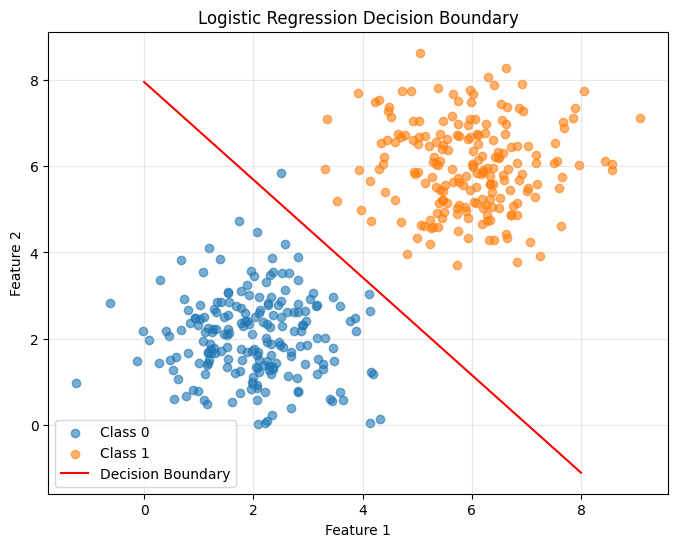

测试集分类准确率: 1.0000


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------
# 1. 生成两类线性可分的数据
# ----------------------
np.random.seed(42)
n_samples = 200
# 类别 0：均值为 [2, 2]，协方差矩阵为 [[1, 0], [0, 1]]
X0 = np.random.multivariate_normal([2, 2], [[1, 0], [0, 1]], n_samples)
y0 = np.zeros((n_samples, 1))
# 类别 1：均值为 [6, 6]，协方差矩阵为 [[1, 0], [0, 1]]
X1 = np.random.multivariate_normal([6, 6], [[1, 0], [0, 1]], n_samples)
y1 = np.ones((n_samples, 1))

# 合并数据
X = np.vstack((X0, X1))
y = np.vstack((y0, y1))

# 划分训练集（题目未要求，直接用全部数据训练）
# 也可以额外生成测试集
n_test = 100
X0_test = np.random.multivariate_normal([2, 2], [[1, 0], [0, 1]], n_test//2)
X1_test = np.random.multivariate_normal([6, 6], [[1, 0], [0, 1]], n_test//2)
X_test = np.vstack((X0_test, X1_test))
y_test = np.vstack((np.zeros((n_test//2, 1)), np.ones((n_test//2, 1))))

# ----------------------
# 2. 定义 sigmoid 函数和二元交叉熵损失
# ----------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    # 避免 log(0)，加上极小值
    loss = (-1/m) * np.sum(y_true * np.log(y_pred + 1e-9) + (1 - y_true) * np.log(1 - y_pred + 1e-9))
    return loss

# ----------------------
# 3. 梯度下降法学习参数 w, b
# ----------------------
# 初始化参数
n_features = X.shape[1]
w = np.zeros((n_features, 1))
b = 0.0
learning_rate = 0.1
epochs = 1000
m = X.shape[0]

for epoch in range(epochs):
    # 前向传播
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y)
    
    # 反向传播（梯度计算）
    dw = (1/m) * np.dot(X.T, (y_pred - y))
    db = (1/m) * np.sum(y_pred - y)
    
    # 更新参数
    w -= learning_rate * dw
    b -= learning_rate * db
    
    # 每 100 次迭代打印一次损失
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

# ----------------------
# 4. 绘制决策边界 + 测试集准确率
# ----------------------
# 绘制数据点
plt.figure(figsize=(8, 6))
plt.scatter(X0[:, 0], X0[:, 1], label='Class 0', alpha=0.6)
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1', alpha=0.6)

# 绘制决策边界：w1*x1 + w2*x2 + b = 0 → x2 = (-w1*x1 - b)/w2
x1 = np.linspace(0, 8, 100)
x2 = (-w[0, 0] * x1 - b) / w[1, 0]
plt.plot(x1, x2, 'r-', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Logistic Regression Decision Boundary')
plt.grid(alpha=0.3)
plt.show()

# 测试集预测
z_test = np.dot(X_test, w) + b
y_pred_test = sigmoid(z_test)
# 概率大于 0.5 判定为类别 1，否则为类别 0
y_pred_labels = (y_pred_test > 0.5).astype(int)
accuracy = np.mean(y_pred_labels == y_test)
print(f"测试集分类准确率: {accuracy:.4f}")